In [21]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


logger = logging.getLogger()
logger.setLevel(logging.INFO)

handler = logging.StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

if not logger.handlers:
    logger.addHandler(handler)

logging.info("System initialized and StreamHandler is active!")

INFO:root:System initialized and StreamHandler is active!


In [55]:
try:
    logging.info("Step 1: Reading and translating the dataset...")

    # 1. Read the file
    file_name = 'Unemployment-data.csv'
    df = pd.read_csv(file_name)

    # 2. Automatic translation
    df.rename(columns={'الربع': 'Quarter', 'الجنس': 'Gender', 'معدل البطالة': 'Unemployment_Rate'}, inplace=True)

    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'ذكور': 'Male', 'إناث': 'Female', 'الإجمالي': 'Total'}).fillna(df['Gender'])

    # 3. Save the new file and download it
    df.to_csv('Saudi_Unemployment_English.csv', index=False)
    files.download('Saudi_Unemployment_English.csv')

    logging.info("Step 1 finished: Download completed successfully!")

except Exception as e:
    logging.error(f"Error in Step 1 (Preprocessing): {e}")

INFO:root:Step 1: Reading and translating the dataset...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO:root:Step 1 finished: Download completed successfully!


In [56]:
try:
    logging.info("Step 2: Starting Deep Cleaning and Transformation...")

    # 1. Remove duplicate rows
    df = df.drop_duplicates()
    logging.info("Duplicates removed.")

    # 2. Check and remove missing values
    logging.info(f"Missing values before cleaning:\n{df.isnull().sum()}")
    df = df.dropna()
    logging.info("Missing values removed.")

    # 3. Keep only Male and Female rows
    df = df[df['Gender'].isin(['Male', 'Female'])]

    # 4. Encode Gender
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    logging.info("Gender encoding complete.")

    # 5. Convert unemployment rate to numeric
    df['Unemployment_Rate'] = pd.to_numeric(df['Unemployment_Rate'], errors='coerce')

    # 6. Extract year and quarter number
    df['Year'] = df['Quarter'].str.split('-').str[0].astype(int)
    df['Quarter_Number'] = df['Quarter'].str.split('-').str[1].str.replace('Q', '').astype(int)

    # 7 & 8. Remove Quarter and Arrange columns
    df = df.drop(columns=['Quarter'])
    df = df[['Year', 'Quarter_Number', 'Gender', 'Unemployment_Rate']]

    # 9. Sort data
    df = df.sort_values(by=['Year', 'Quarter_Number', 'Gender']).reset_index(drop=True)

    # 10. Logging final data state
    logging.info("Cleaning complete. Data summary:")
    logging.info(f"Shape: {df.shape}")
    logging.info(f"Columns: {df.columns.tolist()}")
    logging.info(f"Data types:\n{df.dtypes}")

    # Save cleaned dataset
    df.to_csv('cleaned_unemployment_data.csv', index=False)
    files.download('cleaned_unemployment_data.csv')

    logging.info("Step 2 finished: Cleaned dataset saved and downloaded successfully.")

except Exception as e:
    logging.error(f"Error in Step 2 (Deep Cleaning): {e}")

INFO:root:Step 2: Starting Deep Cleaning and Transformation...
INFO:root:Duplicates removed.
INFO:root:Missing values before cleaning:
Quarter              0
Gender               0
Unemployment_Rate    0
dtype: int64
INFO:root:Missing values removed.
INFO:root:Gender encoding complete.
INFO:root:Cleaning complete. Data summary:
INFO:root:Shape: (76, 4)
INFO:root:Columns: ['Year', 'Quarter_Number', 'Gender', 'Unemployment_Rate']
INFO:root:Data types:
Year                   int64
Quarter_Number         int64
Gender                 int64
Unemployment_Rate    float64
dtype: object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO:root:Step 2 finished: Cleaned dataset saved and downloaded successfully.


In [57]:
try:
    logging.info("Step 3: Preparing time index and model containers...")

    df["t"] = df.groupby("Gender").cumcount()

    test_size = 10

    linear_models = {}
    poly_models = {}
    holt_models = {}

    test_data = {}

    logging.info("Time index created successfully.")
    logging.info(f"Test size set to {test_size}.")
    logging.info("Model containers initialized.")
except Exception as e:
    logging.error(f"Error in Step 3 (Data Preparation): {e}")

INFO:root:Step 3: Preparing time index and model containers...
INFO:root:Time index created successfully.
INFO:root:Test size set to 10.
INFO:root:Model containers initialized.


In [60]:
try:
    logging.info("Step 4: Starting model training...")
    for gender in sorted(df["Gender"].unique()):

        logging.info(f"Training models for Gender = {gender}")

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        X_gender = gdf[["t"]].values
        y_gender = gdf["Unemployment_Rate"].values

        if len(y_gender) <= test_size:
            logging.warning(f"Skipping Gender {gender}: Not enough data.")
            continue

        split_idx = len(y_gender) - test_size

        X_train = X_gender[:split_idx]
        X_test = X_gender[split_idx:]

        y_train = y_gender[:split_idx]
        y_test = y_gender[split_idx:]

        test_data[gender] = {
            "X_test": X_test,
            "y_test": y_test,
            "quarters": gdf["Quarter_Number"].iloc[split_idx:]
        }

        # Linear Regression
        linear_model = LinearRegression()
        linear_model.fit(X_train, y_train)
        linear_models[gender] = linear_model

        logging.info(f"Linear Regression trained successfully for Gender {gender}")

        # Polynomial Regression
        poly_model = make_pipeline(
            PolynomialFeatures(
                degree=2,
                include_bias=False
            ),
            LinearRegression()
        )

        poly_model.fit(X_train, y_train)
        poly_models[gender] = poly_model

        logging.info(f"Polynomial Regression trained successfully for Gender {gender}")

        # Holt-Winters
        hw = ExponentialSmoothing(
            y_train,
            trend="add",
            seasonal="add",
            seasonal_periods=4
        ).fit(optimized=True)

        holt_models[gender] = hw

        logging.info(f"Holt-Winters trained successfully for Gender {gender}")

    logging.info("All models trained successfully.")
except Exception as e:
    logging.error(f"Error in Step 4 (Model Training): {e}")

INFO:root:Step 4: Starting model training...
INFO:root:Training models for Gender = 0
INFO:root:Linear Regression trained successfully for Gender 0
INFO:root:Polynomial Regression trained successfully for Gender 0
INFO:root:Holt-Winters trained successfully for Gender 0
INFO:root:Training models for Gender = 1
INFO:root:Linear Regression trained successfully for Gender 1
INFO:root:Polynomial Regression trained successfully for Gender 1
INFO:root:Holt-Winters trained successfully for Gender 1
INFO:root:All models trained successfully.


In [61]:
try:
    logging.info("Step 5: Evaluating Linear Regression model...")

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    import pandas as pd

    all_results = []

    gender_names = {
        0: "Male",
        1: "Female"
    }

    for gender in sorted(df["Gender"].unique()):

        gender_name = gender_names.get(gender, str(gender))

        logging.info(f"Evaluating Linear Regression for {gender_name}")

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        X_gender = gdf[["t"]].values
        y_gender = gdf["Unemployment_Rate"].values

        split_idx = len(y_gender) - test_size

        X_test = X_gender[split_idx:]
        y_test = y_gender[split_idx:]

        y_test_pred = linear_models[gender].predict(X_test)

        mae = mean_absolute_error(y_test, y_test_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2 = r2_score(y_test, y_test_pred)

        all_results.append({
            "Gender": gender_name,
            "Model": "Linear Regression",
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

        logging.info(
            f"{gender_name} | MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}"
        )

    logging.info("Linear Regression evaluation completed successfully.")

except Exception as e:
    logging.error(f"Error in Step 5 (Linear Regression Evaluation): {e}")

INFO:root:Step 5: Evaluating Linear Regression model...
INFO:root:Evaluating Linear Regression for Male
INFO:root:Male | MAE=0.665, RMSE=0.709, R²=-3.858
INFO:root:Evaluating Linear Regression for Female
INFO:root:Female | MAE=2.165, RMSE=2.334, R²=-0.600
INFO:root:Linear Regression evaluation completed successfully.


In [62]:
try:
    logging.info("Step 6: Evaluating Polynomial Regression model...")

    for gender in sorted(df["Gender"].unique()):

        gender_name = gender_names.get(gender, str(gender))

        logging.info(f"Evaluating Polynomial Regression for {gender_name}")

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        X_gender = gdf[["t"]].values
        y_gender = gdf["Unemployment_Rate"].values

        split_idx = len(y_gender) - test_size

        X_test = X_gender[split_idx:]
        y_test = y_gender[split_idx:]

        y_test_pred = poly_models[gender].predict(X_test)

        mae = mean_absolute_error(y_test, y_test_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2 = r2_score(y_test, y_test_pred)

        all_results.append({
            "Gender": gender_name,
            "Model": "Polynomial Regression",
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

        logging.info(
            f"{gender_name} | MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}"
        )

    logging.info("Polynomial Regression evaluation completed successfully.")

except Exception as e:
    logging.error(f"Error in Step 6 (Polynomial Regression Evaluation): {e}")

INFO:root:Step 6: Evaluating Polynomial Regression model...
INFO:root:Evaluating Polynomial Regression for Male
INFO:root:Male | MAE=2.472, RMSE=2.807, R²=-75.069
INFO:root:Evaluating Polynomial Regression for Female
INFO:root:Female | MAE=6.256, RMSE=7.115, R²=-13.871
INFO:root:Polynomial Regression evaluation completed successfully.


In [63]:
try:
    logging.info("Step 7: Evaluating Holt-Winters model...")

    for gender in sorted(df["Gender"].unique()):

        gender_name = gender_names.get(gender, str(gender))

        logging.info(f"Evaluating Holt-Winters for {gender_name}")

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        y_gender = gdf["Unemployment_Rate"].values

        split_idx = len(y_gender) - test_size

        y_test = y_gender[split_idx:]

        y_test_pred = holt_models[gender].forecast(len(y_test))

        mae = mean_absolute_error(y_test, y_test_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2 = r2_score(y_test, y_test_pred)

        all_results.append({
            "Gender": gender_name,
            "Model": "Holt-Winters",
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

        logging.info(
            f"{gender_name} | MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}"
        )

    logging.info("Holt-Winters evaluation completed successfully.")

except Exception as e:
    logging.error(f"Error in Step 7 (Holt-Winters Evaluation): {e}")

INFO:root:Step 7: Evaluating Holt-Winters model...
INFO:root:Evaluating Holt-Winters for Male
INFO:root:Male | MAE=0.334, RMSE=0.393, R²=-0.492
INFO:root:Evaluating Holt-Winters for Female
INFO:root:Female | MAE=0.567, RMSE=0.642, R²=0.879
INFO:root:Holt-Winters evaluation completed successfully.


In [64]:
try:
    logging.info("Step 8: Generating Male Results table...")

    results_by_gender = pd.DataFrame(all_results).round(3)

    male_results = results_by_gender[
        results_by_gender["Gender"] == "Male"
    ].drop(columns=["Gender"])

    logging.info(
        f"Male Results generated successfully ({len(male_results)} rows)."
    )

    display(male_results)

except Exception as e:
    logging.error(f"Error in Step 8 (Male Results): {e}")

INFO:root:Step 8: Generating Male Results table...
INFO:root:Male Results generated successfully (3 rows).


,Model,MAE,RMSE,R²
0,Linear Regression,0.665,0.709,-3.858
2,Polynomial Regression,2.472,2.807,-75.069
4,Holt-Winters,0.334,0.393,-0.492


In [65]:
try:
    logging.info("Step 9: Generating Female Results table...")

    female_results = results_by_gender[
        results_by_gender["Gender"] == "Female"
    ].drop(columns=["Gender"])

    logging.info(
        f"Female Results generated successfully ({len(female_results)} rows)."
    )

    display(female_results)

except Exception as e:
    logging.error(f"Error in Step 9 (Female Results): {e}")

INFO:root:Step 9: Generating Female Results table...
INFO:root:Female Results generated successfully (3 rows).


,Model,MAE,RMSE,R²
1,Linear Regression,2.165,2.334,-0.600
3,Polynomial Regression,6.256,7.115,-13.871
5,Holt-Winters,0.567,0.642,0.879


In [66]:
try:
    logging.info("Step 10: Calculating average model performance...")

    average_results = (
        results_by_gender
        .groupby("Model")[["MAE", "RMSE", "R²"]]
        .mean()
        .reset_index()
        .round(3)
    )

    average_results = average_results.sort_values(
        by="R²",
        ascending=False
    ).reset_index(drop=True)

    logging.info("Average results calculated successfully.")

    display(average_results)

except Exception as e:
    logging.error(f"Error in Step 10 (Average Results): {e}")

INFO:root:Step 10: Calculating average model performance...
INFO:root:Average results calculated successfully.


,Model,MAE,RMSE,R²
0,Holt-Winters,0.450,0.518,0.194
1,Linear Regression,1.415,1.522,-2.229
2,Polynomial Regression,4.364,4.961,-44.470


In [67]:
try:
    logging.info("Step 11: Selecting best model based on average R²...")

    best_model = average_results.loc[
        average_results["R²"].idxmax()
    ]

    logging.info(
        f"Best Model: {best_model['Model']} | "
        f"R²={best_model['R²']:.3f} | "
        f"MAE={best_model['MAE']:.3f} | "
        f"RMSE={best_model['RMSE']:.3f}"
    )

    print("Best Model Based on Average R²")
    print("Model:", best_model["Model"])
    print("Average R²:", best_model["R²"])
    print("Average MAE:", best_model["MAE"])
    print("Average RMSE:", best_model["RMSE"])

except Exception as e:
    logging.error(f"Error in Step 11 (Best Model Selection): {e}")

INFO:root:Step 11: Selecting best model based on average R²...
INFO:root:Best Model: Holt-Winters | R²=0.194 | MAE=0.450 | RMSE=0.518


Best Model Based on Average R²
Model: Holt-Winters
Average R²: 0.194
Average MAE: 0.45
Average RMSE: 0.518


INFO:root:Step 12: Generating Linear Regression visualizations...
INFO:root:Generating Linear Regression plot for Male


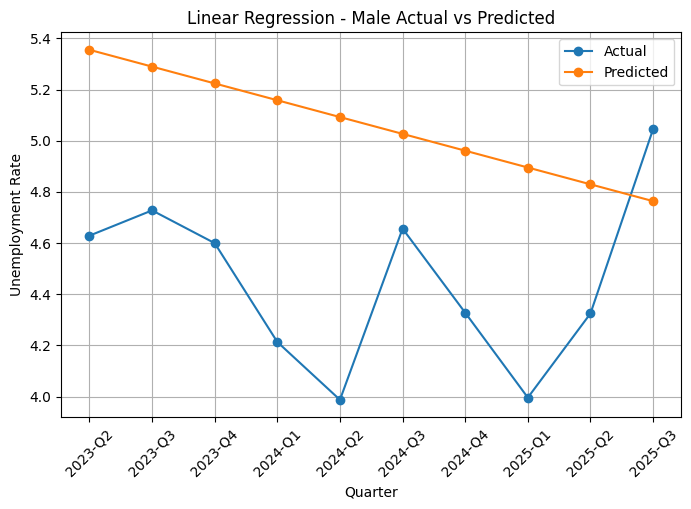

INFO:root:Generating Linear Regression plot for Female


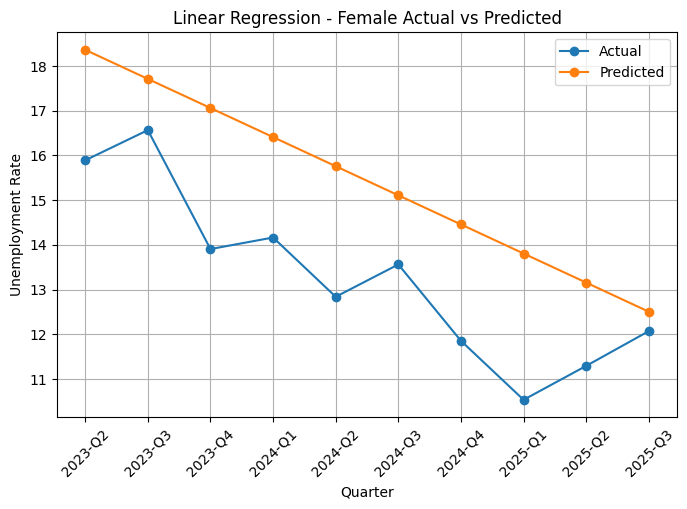

INFO:root:Linear Regression visualizations generated successfully.


In [68]:
try:
    logging.info("Step 12: Generating Linear Regression visualizations...")

    for gender in sorted(df["Gender"].unique()):

        gender_name = gender_names.get(gender, str(gender))

        logging.info(
            f"Generating Linear Regression plot for {gender_name}"
        )

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        X_gender = gdf[["t"]].values
        y_gender = gdf["Unemployment_Rate"].values

        split_idx = len(y_gender) - test_size

        X_test = X_gender[split_idx:]
        y_test = y_gender[split_idx:]

        y_test_pred = linear_models[gender].predict(X_test)

        quarters = (
            gdf["Year"].astype(str)
            + "-Q"
            + gdf["Quarter_Number"].astype(str)
        ).iloc[split_idx:].values

        plt.figure(figsize=(8, 5))
        plt.plot(quarters, y_test, marker="o", label="Actual")
        plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

        plt.title(f"Linear Regression - {gender_name} Actual vs Predicted")
        plt.xlabel("Quarter")
        plt.ylabel("Unemployment Rate")
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.show()

    logging.info("Linear Regression visualizations generated successfully.")

except Exception as e:
    logging.error(f"Error in Step 12 (Linear Regression Visualization): {e}")

INFO:root:Step 13: Generating Polynomial Regression visualizations...
INFO:root:Generating Polynomial Regression plot for Male


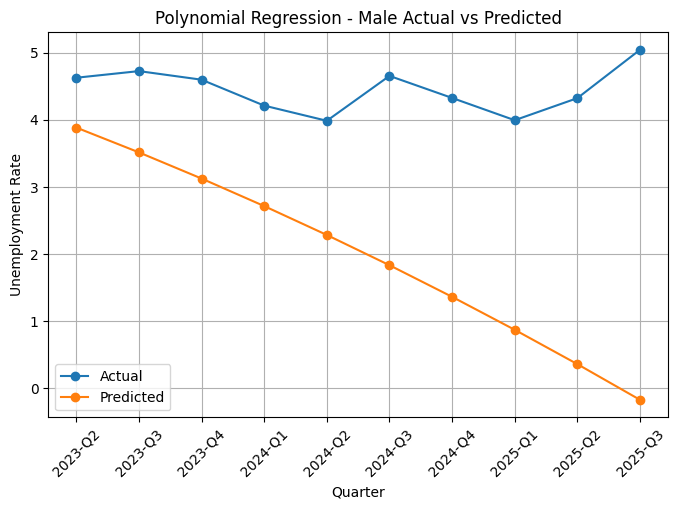

INFO:root:Generating Polynomial Regression plot for Female


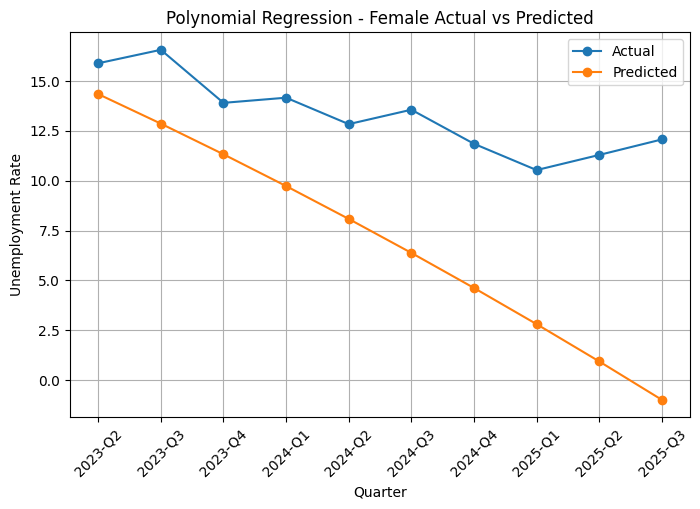

INFO:root:Polynomial Regression visualizations generated successfully.


In [69]:
try:
    logging.info("Step 13: Generating Polynomial Regression visualizations...")

    for gender in sorted(df["Gender"].unique()):

        gender_name = gender_names.get(gender, str(gender))

        logging.info(
            f"Generating Polynomial Regression plot for {gender_name}"
        )

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        X_gender = gdf[["t"]].values
        y_gender = gdf["Unemployment_Rate"].values

        split_idx = len(y_gender) - test_size

        X_test = X_gender[split_idx:]
        y_test = y_gender[split_idx:]

        y_test_pred = poly_models[gender].predict(X_test)

        quarters = (
            gdf["Year"].astype(str)
            + "-Q"
            + gdf["Quarter_Number"].astype(str)
        ).iloc[split_idx:].values

        plt.figure(figsize=(8, 5))
        plt.plot(quarters, y_test, marker="o", label="Actual")
        plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

        plt.title(f"Polynomial Regression - {gender_name} Actual vs Predicted")
        plt.xlabel("Quarter")
        plt.ylabel("Unemployment Rate")
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.show()

    logging.info("Polynomial Regression visualizations generated successfully.")

except Exception as e:
    logging.error(f"Error in Step 13 (Polynomial Regression Visualization): {e}")

INFO:root:Step 14: Generating Holt-Winters visualizations...
INFO:root:Generating Holt-Winters plot for Male


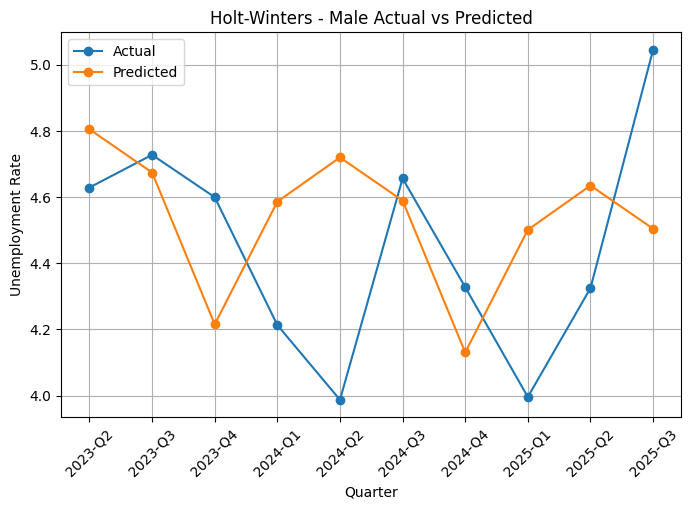

INFO:root:Generating Holt-Winters plot for Female


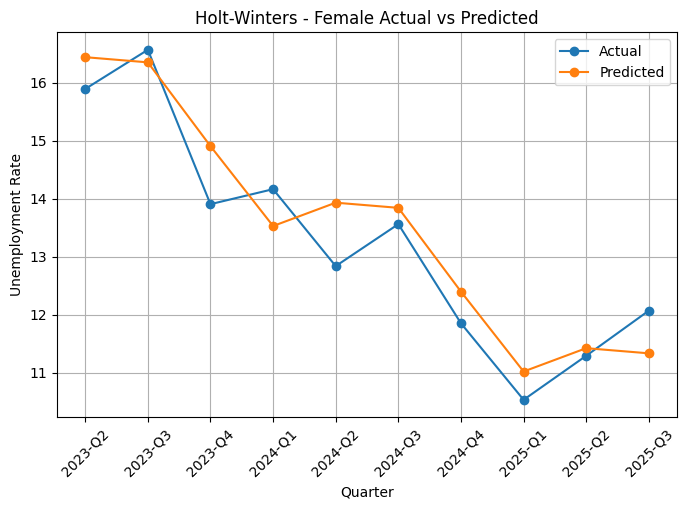

INFO:root:Holt-Winters visualizations generated successfully.


In [70]:
try:
    logging.info("Step 14: Generating Holt-Winters visualizations...")

    for gender in sorted(df["Gender"].unique()):

        gender_name = gender_names.get(gender, str(gender))

        logging.info(
            f"Generating Holt-Winters plot for {gender_name}"
        )

        gdf = (
            df[df["Gender"] == gender]
            .copy()
            .sort_values(["Year", "Quarter_Number"])
            .reset_index(drop=True)
        )

        y_gender = gdf["Unemployment_Rate"].values

        split_idx = len(y_gender) - test_size

        y_test = y_gender[split_idx:]
        y_test_pred = holt_models[gender].forecast(len(y_test))

        quarters = (
            gdf["Year"].astype(str)
            + "-Q"
            + gdf["Quarter_Number"].astype(str)
        ).iloc[split_idx:].values

        plt.figure(figsize=(8, 5))
        plt.plot(quarters, y_test, marker="o", label="Actual")
        plt.plot(quarters, y_test_pred, marker="o", label="Predicted")

        plt.title(f"Holt-Winters - {gender_name} Actual vs Predicted")
        plt.xlabel("Quarter")
        plt.ylabel("Unemployment Rate")
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.show()

    logging.info("Holt-Winters visualizations generated successfully.")

except Exception as e:
    logging.error(f"Error in Step 14 (Holt-Winters Visualization): {e}")

In [71]:
import os
import pandas as pd

# Test 1: Dataset loaded correctly
assert not df.empty, "Dataset is empty"

# Test 2: Target column exists
assert "Unemployment_Rate" in df.columns, "Target column missing"

# Test 3: No missing values after preprocessing
assert df.isnull().sum().sum() == 0, "Missing values found"

# Test 4: Integration test between preprocessing and training modules

# Verify that the cleaned dataset file was created
assert os.path.exists("cleaned_unemployment_data.csv"), "Cleaned dataset file not found"

# Load the cleaned dataset created in the preprocessing module
cleaned_df = pd.read_csv("cleaned_unemployment_data.csv")

# Verify that the cleaned dataset is not empty
assert not cleaned_df.empty, "Cleaned dataset is empty"

# Verify that the target column still exists
assert "Unemployment_Rate" in cleaned_df.columns, "Target column missing in cleaned dataset"

# Test 5: Model generated predictions
# To resolve NameError, re-calculating predictions for a specific gender (e.g., Male, gender=0)
# This assumes that the intent is to test *a* model's predictions, not all of them.

# Retrieve test data for gender 0
X_test_lr_0 = test_data[0]["X_test"]
y_test_lr_0 = test_data[0]["y_test"]

# Get predictions from the linear model for gender 0
y_test_pred_lr_0 = linear_models[0].predict(X_test_lr_0)

assert len(y_test_pred_lr_0) > 0, "No predictions generated for Linear Regression (Male)"

# Verify prediction output size matches test labels
assert len(y_test_pred_lr_0) == len(y_test_lr_0), "Prediction size does not match test set size for Linear Regression (Male)"

print("All tests passed successfully.")

All tests passed successfully.


In [76]:
# LOAD & STRESS TESTING SECTION

import time
from statsmodels.tsa.holtwinters import ExponentialSmoothing

for gender in sorted(df["Gender"].unique()):
    gender_name = gender_names.get(gender, str(gender))
    print(f"\n   Testing Holt-Winters model for {gender_name} ")

    # Retrieve train and test data for the current gender
    # X_train is not strictly needed for ExponentialSmoothing, but y_train and X_test length are.
    # However, to be consistent with previous structure, we'll extract them.
    # Note: For ExponentialSmoothing, y_train is the time series itself, and X_test is used to get the number of steps for forecasting.
    y_train_gender = df[df["Gender"] == gender].sort_values(["Year", "Quarter_Number"])["Unemployment_Rate"].iloc[:-test_size].values
    X_test_gender = test_data[gender]["X_test"]

    # Measure training time by re-instantiating and fitting a new Holt-Winters model
    start_time = time.time()
    model_instance = ExponentialSmoothing(
        y_train_gender,
        trend="add",
        seasonal="add",
        seasonal_periods=4
    )
    fitted_model_results = model_instance.fit(optimized=True)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time ({gender_name}): {training_time:.4f} seconds")

    # Use the fitted model for predictions
    model = fitted_model_results # 'model' now refers to the HoltWintersResults object

    # Measure prediction time
    start_time = time.time()
    # Use .forecast(steps) for HoltWintersResults to predict future steps
    predictions = model.forecast(len(X_test_gender))
    end_time = time.time()
    prediction_time = end_time - start_time
    print(f"Prediction Time ({gender_name}): {prediction_time:.4f} seconds")


    # Run predictions 100 times (Stress Test)
    start_time = time.time()
    for _ in range(100):
        predictions = model.forecast(len(X_test_gender)) # Use .forecast(steps)
    end_time = time.time()
    print(f"100 prediction runs completed ({gender_name}) in {end_time - start_time:.4f} seconds")


   Testing Holt-Winters model for Male 
Training Time (Male): 0.0970 seconds
Prediction Time (Male): 0.0013 seconds
100 prediction runs completed (Male) in 0.1222 seconds

   Testing Holt-Winters model for Female 
Training Time (Female): 0.1371 seconds
Prediction Time (Female): 0.0037 seconds
100 prediction runs completed (Female) in 0.1890 seconds
